# GSAM Annotation Generation Pipeline

This notebook handles the GSAM segmentation part of the artifact generation pipeline:
1. GSAM segmentation to identify parts and create artifact annotations
2. Save annotations to intermediate files for use in FLUX generation

The output annotations will be saved to `src/notebooks/annotations/` directory.


In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import os
os.chdir('/home/jhpark/image-artifacts/src')
os.environ["CUDA_VISIBLE_DEVICES"] = "1"


In [3]:
# Install required packages if needed
# !pip install torch torchvision transformers openai PIL numpy tqdm matplotlib
# !pip install groundingdino-py segment-anything

import sys
import uuid
import json
import time
import logging
import pickle
import random
import shutil
from datetime import datetime
from typing import List, Dict, Optional, Tuple, Any
import traceback
from collections import defaultdict

import numpy as np
import openai
import torch
from tqdm import tqdm
from PIL import Image
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import matplotlib.pyplot as plt

# Add pipeline to path
from pipeline import (
    GSAMDetector, InstanceProcessor, ImageVisualizer,
)
from pipeline.data_loader import _initialize_data_loader, _get_image_list
from pipeline.prompts import get_entity_subentities, MoneyManager


/home/jhpark/anaconda3/envs/gsam/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Configuration - modify these as needed
CONFIG = {
    # Dataset configuration
    'dataset_type': 'coco',
    'dataset_path': '/data3/jhpark/coco/annotations',
    'image_path': '/data3/jhpark/coco/train2017',
    'super_categories': ['animal'],  # Process animal images
    
    # Processing parameters
    'max_images': 1,  # Process only one image
    'max_artifacts_per_image': 2,  # Generate 2 artifacts per image
    'artifact_types': ['fusion', 'distortion', 'removal', 'addition'],
    
    # GSAM parameters
    'min_area_ratio': 0.005,
    'max_area_ratio': 0.5,
    'box_threshold': 0.3,
    'text_threshold': 0.25,
    'device': 'cuda:0' if torch.cuda.is_available() else 'cpu',
    
    # Model paths (adjust if needed)
    'grounding_config_file': 'GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py',
    'grounding_checkpoint': 'weight/groundingdino_swint_ogc.pth',
    'sam_version': 'vit_h',
    'sam_checkpoint': 'weight/sam_vit_h_4b8939.pth',
    'sam_hq_checkpoint': None,
    'use_sam_hq': False,
    'bert_base_uncased_path': None,
    
    # Output directory for annotations
    'annotation_output_dir': '/data3/jhpark/fusion/annotations',
    
    # FLUX parameters (for reference, not used in this notebook)
    'guidance': 5.0,
    'num_steps': 25,
    'inject_step': 20,
    'pe_step_addition': 25,
    'pe_step_removal': 25,
    'pe_step_distortion': 20,
    'pe_step_fusion': 20,
    'seed': 42,
    'use_rf_solver': False
}

# Set random seed for reproducibility
random.seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG['seed'])

print("Configuration loaded:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")


Configuration loaded:
  dataset_type: coco
  dataset_path: /data3/jhpark/coco/annotations
  image_path: /data3/jhpark/coco/train2017
  super_categories: ['animal']
  max_images: 1
  max_artifacts_per_image: 2
  artifact_types: ['fusion', 'distortion', 'removal', 'addition']
  min_area_ratio: 0.005
  max_area_ratio: 0.5
  box_threshold: 0.3
  text_threshold: 0.25
  device: cuda:0
  grounding_config_file: GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py
  grounding_checkpoint: weight/groundingdino_swint_ogc.pth
  sam_version: vit_h
  sam_checkpoint: weight/sam_vit_h_4b8939.pth
  sam_hq_checkpoint: None
  use_sam_hq: False
  bert_base_uncased_path: None
  annotation_output_dir: /data3/jhpark/fusion/annotations
  guidance: 5.0
  num_steps: 25
  inject_step: 20
  pe_step_addition: 25
  pe_step_removal: 25
  pe_step_distortion: 20
  pe_step_fusion: 20
  seed: 42
  use_rf_solver: False


In [5]:
# Initialize OpenAI client
if not os.getenv('OPENAI_API_KEY'):
    print("❌ Error: OPENAI_API_KEY environment variable not set.")
    print("Please set your OpenAI API key:")
    print("  export OPENAI_API_KEY='your-api-key-here'")
else:
    openai_client = openai.OpenAI()
    print("✅ OpenAI client initialized")

# Initialize MoneyManager for tracking API costs
money_manager = MoneyManager(model="gpt-4o")


✅ OpenAI client initialized


In [6]:
# Initialize models and components
print("Initializing components...")

# Initialize data loader
data_loader = _initialize_data_loader(CONFIG['dataset_type'], CONFIG)
print("✅ Data loader initialized")

# Initialize BLIP model for captioning
blip_processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")
blip_model = Blip2ForConditionalGeneration.from_pretrained("Salesforce/blip2-opt-2.7b", device_map="cuda:0")
print("✅ BLIP model initialized")

# Initialize GSAM detector with error handling
print("Checking model file paths...")
print(f"Grounding config: {CONFIG['grounding_config_file']}")
print(f"Grounding checkpoint: {CONFIG['grounding_checkpoint']}")
print(f"SAM checkpoint: {CONFIG['sam_checkpoint']}")

# Check if files exist
import os
missing_files = []
if not os.path.exists(CONFIG['grounding_config_file']):
    missing_files.append(f"Grounding config: {CONFIG['grounding_config_file']}")
if not os.path.exists(CONFIG['grounding_checkpoint']):
    missing_files.append(f"Grounding checkpoint: {CONFIG['grounding_checkpoint']}")
if not os.path.exists(CONFIG['sam_checkpoint']):
    missing_files.append(f"SAM checkpoint: {CONFIG['sam_checkpoint']}")

if missing_files:
    print("❌ Missing model files:")
    for file in missing_files:
        print(f"  {file}")
    print("")
    print("Please download the required model files:")
    print("1. GroundingDINO: https://github.com/IDEA-Research/GroundingDINO")
    print("2. SAM: https://github.com/facebookresearch/segment-anything")
    print("")
    print("You can also update the paths in CONFIG to point to the correct locations.")
    raise FileNotFoundError("Required model files are missing")

try:
    gsam_detector = GSAMDetector(
        grounding_config_file=CONFIG['grounding_config_file'],
        grounding_checkpoint=CONFIG['grounding_checkpoint'],
        sam_version=CONFIG['sam_version'],
        sam_checkpoint=CONFIG['sam_checkpoint'],
        sam_hq_checkpoint=CONFIG['sam_hq_checkpoint'],
        use_sam_hq=CONFIG['use_sam_hq'],
        box_threshold=CONFIG['box_threshold'],
        text_threshold=CONFIG['text_threshold'],
        bert_base_uncased_path=CONFIG['bert_base_uncased_path'],
        device=CONFIG['device'],
        openai_client=openai_client
    )
    
    # Verify the model was initialized properly
    if gsam_detector.grounding_model is None:
        raise RuntimeError("GroundingDINO model failed to initialize (grounding_model is None)")
    
    print("✅ GSAM detector initialized successfully")

except Exception as e:
    print(f"❌ Error initializing GSAM detector: {e}")
    print("")
    print("This might be due to:")
    print("1. Missing or corrupted model files")
    print("2. Incorrect file paths")
    print("3. CUDA/GPU memory issues")
    print("4. Missing dependencies (GroundingDINO, segment-anything)")
    print("5. PyTorch/CUDA version compatibility issues")
    print("")
    print("Troubleshooting steps:")
    print("- Check that all model files exist at the specified paths")
    print("- Ensure you have sufficient GPU memory (at least 8GB recommended)")
    print("- Try using device='cpu' in CONFIG if GPU issues persist")
    print("- Make sure GroundingDINO and segment-anything are properly installed")
    raise

# Initialize visualizer
visualizer = ImageVisualizer()
print("✅ All components initialized successfully!")


Initializing components...
loading annotations into memory...
Done (t=0.79s)
creating index...
index created!
loading annotations into memory...
Done (t=15.19s)
creating index...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


index created!
✅ Data loader initialized


Loading checkpoint shards: 100%|██████████| 2/2 [00:11<00:00,  5.53s/it]


✅ BLIP model initialized
Checking model file paths...
Grounding config: GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py
Grounding checkpoint: weight/groundingdino_swint_ogc.pth
SAM checkpoint: weight/sam_vit_h_4b8939.pth


final text_encoder_type: bert-base-uncased


✅ GSAM detector initialized successfully
✅ All components initialized successfully!


In [7]:
# Helper function to convert mask to patch coordinates
def mask_to_patch_coords(mask, patch_size=16):
    """Convert binary mask to patch coordinates"""
    from pipeline.instance_processor import mask_to_patch_coords
    return mask_to_patch_coords(mask, patch_size)

# GSAM Segmentation Processing Functions - Up to Step 3
def process_gsam_segmentation_to_step3(img_array, entities, gsam_detector, openai_client, money_manager, config, logger):
    """Process single image with GSAM segmentation up to step 3 of fusion patch creation"""
    
    logger.info("Getting entity subparts for all artifact types...")
    
    # Step 2: Single detection call with combined vocabulary
    logger.info("Detecting parts using Grounded SAM...")
    entity_predictions, visualized_output = gsam_detector.detect_entities(
        img_array, entities, min_area_ratio=config['min_area_ratio'], max_area_ratio=config['max_area_ratio']
    )
    
    # Step 3: Process up to overlap detection (Step 3 of create_fusion_artifact_patches)
    logger.info("Finding overlapping entities and creating overlap regions...")

    step3_data_list = []
    for entity_prediction in entity_predictions:
        entity = entity_prediction['entity']
        try:
            step3_data = create_fusion_step3_data(
                entity_prediction,
                entity_predictions,
                img_array,
                patch_size=16
            )
            if step3_data:
                step3_data_list.append(step3_data)
        except Exception as e:
            import traceback
            tb_str = traceback.format_exc()
            logger.error(f"Cannot create step 3 data for {entity}: {str(e)}\nTraceback:\n{tb_str}")
            continue

    if len(step3_data_list) == 0:
        raise ValueError("No valid overlapping entities found")
        
    logger.info(f"✅ Successfully created step 3 data for {len(step3_data_list)} entities")
    
    return step3_data_list, visualized_output

def create_fusion_step3_data(entity_prediction, entity_predictions, img_array, patch_size=16):
    """
    Execute steps 1-3 of create_fusion_artifact_patches and return intermediate data.
    This stops right after creating the overlapping region.
    """
    H, W = img_array.shape[:2]
    patch_H = (H // patch_size) * patch_size
    patch_W = (W // patch_size) * patch_size
    patch_w = patch_W // patch_size
    patch_h = patch_H // patch_size

    # Get entity A (current entity) information
    entity_A = entity_prediction['entity']
    mask_A = entity_prediction['pred_mask'].cpu().numpy()
    
    mask_A_patch_coords = mask_to_patch_coords(mask_A, patch_size=patch_size)
    mask_A_patch_set = set(mask_A_patch_coords)

    # Step 1: Find overlapping instances for the same entity
    overlapping_candidates = []
    for i, other_prediction in enumerate(entity_predictions):
        if other_prediction['entity'] == entity_A:
            # Skip if same instance
            if torch.equal(entity_prediction['pred_box'], other_prediction['pred_box']):
                continue
            
            mask_B = other_prediction['pred_mask'].cpu().numpy()
            
            # Convert mask B to patch coordinates
            mask_B_patch_coords = mask_to_patch_coords(mask_B, patch_size=patch_size)
            mask_B_patch_set = set(mask_B_patch_coords)
            
            # Calculate intersection and areas using patch coordinate sets
            intersection_patches = mask_A_patch_set & mask_B_patch_set
            intersection = len(intersection_patches)
            area_A = len(mask_A_patch_set)
            area_B = len(mask_B_patch_set)
            
            if area_A == 0 or area_B == 0:
                continue
            
            # Containment ratio (how much each instance contains the other)
            containment_A_in_B = intersection / area_A
            containment_B_in_A = intersection / area_B
            
            # Filter out instances that contain one another (containment ratio >= 0.7)
            if containment_A_in_B >= 0.7 or containment_B_in_A >= 0.7:
                continue
            
            if intersection > 5:
                overlapping_candidates.append({
                    'index': i,
                    'prediction': other_prediction,
                    'mask_B_patch_set': list(mask_B_patch_set),
                    'intersection': intersection
                })

    if not overlapping_candidates:
        raise ValueError("No valid overlapping entity found for fusion artifact")

    # Step 2: Select entity with highest overlap
    best_candidate = max(overlapping_candidates, key=lambda x: x['intersection'])
    entity_B_prediction = best_candidate['prediction']
    mask_B_patch_set = set(best_candidate['mask_B_patch_set'])
    mask_B_patch_coords = list(mask_B_patch_set)

    # Step 3: Create overlapping region using patch coordinate intersection
    overlap_patch_set = mask_A_patch_set & mask_B_patch_set
    overlap_patch_coords = list(overlap_patch_set)

    # Return all the intermediate data needed for step 4+ processing
    return {
        'entity_A': entity_A,
        'entity_B': entity_B_prediction['entity'],
        'entity_A_prediction': {
            'entity': entity_prediction['entity'],
            'pred_box': entity_prediction['pred_box'].cpu().numpy().tolist(),
            # 'pred_mask': mask_A.tolist(),  # Convert to list for JSON serialization
        },
        'entity_B_prediction': {
            'entity': entity_B_prediction['entity'],
            'pred_box': entity_B_prediction['pred_box'].cpu().numpy().tolist(),
            # 'pred_mask': list(mask_B_patch_set),  # Already processed to patch coords
        },
        'mask_A_patch_coords': mask_A_patch_coords,
        'mask_B_patch_coords': mask_B_patch_coords,
        'mask_A_patch_set': list(mask_A_patch_set),
        'mask_B_patch_set': list(mask_B_patch_set),
        'overlap_patch_coords': overlap_patch_coords,
        'image_dimensions': {
            'H': H, 'W': W,
            'patch_H': patch_H, 'patch_W': patch_W,
            'patch_h': patch_h, 'patch_w': patch_w
        },
        'patch_size': patch_size,
        'artifact_type': 'fusion'
    }

print("GSAM segmentation functions (up to step 3) loaded")


GSAM segmentation functions (up to step 3) loaded


In [8]:
# Load image list and process GSAM segmentation
print("Loading image list...")
image_list = _get_image_list(
    CONFIG['dataset_type'], 
    data_loader, 
    CONFIG['super_categories'], 
    CONFIG['max_images'],
    max_instances_per_image=5,
    logger=logging.getLogger()
)
random.shuffle(image_list)

print(f"Found {len(image_list)} images")
if len(image_list) == 0:
    print("❌ No images found. Please check your dataset path and categories.")
else:
    print("✅ Image list loaded")
    
# Select first image
image_iter = iter(image_list)

Loading image list...
Counting instances per image...
number of images 15474
Found 15474 images
✅ Image list loaded


In [ ]:
# Process images to find one with fusion artifacts
artifacts = None
img_array = None
img_info = None
caption = None
visualized_output = None

for img_info in image_list:
    # Load and display the selected image
    img_info = next(image_iter)
    if hasattr(data_loader, 'load_image_by_info'):
        img_array = data_loader.load_image_by_info(img_info)
    else:
        img_array = data_loader.load_image_by_path(img_info['file_path'])

    anns = [ann for ann in data_loader.coco_class.dataset['annotations'] if ann['image_id'] == img_info['id']]
    # Convert category_id to category name for each annotation
    for ann in anns:
        cat_id = ann['category_id']
        # Get category name from COCO categories
        for cat in data_loader.coco_class.dataset['categories']:
            if cat['id'] == cat_id:
                cat_name = cat['name']
                break
        ann['category_name'] = cat_name
    entities = list(set([ann['category_name'] for ann in anns]))
    # Run GSAM segmentation
    logger = logging.getLogger()
    logger.setLevel(logging.INFO)

    print(f"Processing image: {img_info['file_name']} (ID: {img_info['id']})")
    print("Running GSAM segmentation...")
    start_time = time.time()
    try:
        step3_data_list, visualized_output = process_gsam_segmentation_to_step3(
            img_array, entities, gsam_detector, openai_client, money_manager, CONFIG, logger
            )
    except Exception as e:
        # print(f"❌ Error in GSAM segmentation: {str(e)}")
        continue
        

    print(f"Found {len(step3_data_list)} overlapping entity pairs:")
    for i, step3_data in enumerate(step3_data_list):
        print(f"  Artifact {i+1}: {'fusion'} - {step3_data['entity_A']}")
        if 'fusion' == 'fusion':
            print(f"    Fused entity: {step3_data['entity_B']}")

    # Generate caption using BLIP
    print("Generating caption...")
    inputs = blip_processor(img_array, return_tensors="pt").to(CONFIG['device'])
    out = blip_model.generate(**inputs)
    caption = blip_processor.decode(out[0], skip_special_tokens=True).strip()
    print(f"Caption: {caption}")

    print("Saving annotation data for FLUX generation...")
    
    # Create annotation output directory
    annotation_dir = CONFIG['annotation_output_dir']
    os.makedirs(annotation_dir, exist_ok=True)
    
    # Generate unique filename based on image info and timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    base_filename = f"{img_info['id']}_{timestamp}_step3"
    
    # Convert numpy arrays to lists for JSON serialization
    def convert_numpy_to_list(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, dict):
            return {k: convert_numpy_to_list(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [convert_numpy_to_list(item) for item in obj]
        else:
            return obj
    
    # Prepare annotation data
    annotation_data = {
        'image_info': img_info,
        'caption': caption,
        'step3_data_list': step3_data_list,
        'image_shape': img_array.shape,
        'config': CONFIG,
        'api_cost': money_manager.total_cost,
        'timestamp': timestamp
    }
    
    # Save annotation file
    annotation_file = os.path.join(annotation_dir, f"{base_filename}_step3_data.json")
    with open(annotation_file, 'w') as f:
        json.dump(annotation_data, f, indent=2)
    
    # Save image array as numpy file
    image_file = os.path.join(annotation_dir, f"{base_filename}_image.npy")
    np.save(image_file, img_array)
    
    # Save visualization if available
    if visualized_output is not None:
        viz_file = os.path.join(annotation_dir, f"{base_filename}_visualization.npy")
        np.save(viz_file, visualized_output)
    
    print(f"✅ Annotation data saved:")
    print(f"  Annotations: {annotation_file}")
    print(f"  Image array: {image_file}")
    if visualized_output is not None:
        print(f"  Visualization: {viz_file}")
    print(f"  Base filename: {base_filename}")
    
    # Store the base filename for use in FLUX notebook
    saved_annotation_id = base_filename
    print(f"\\n📝 To load this data in the FLUX notebook, use step3_id: '{saved_annotation_id}'")

Processing image: 000000333216.jpg (ID: 333216)
Running GSAM segmentation...


Before NMS: 2 boxes


Cannot create step 3 data for horse: No valid overlapping entity found for fusion artifact
Traceback:
Traceback (most recent call last):
  File "/tmp/ipykernel_3316043/1697373468.py", line 26, in process_gsam_segmentation_to_step3
    step3_data = create_fusion_step3_data(
  File "/tmp/ipykernel_3316043/1697373468.py", line 105, in create_fusion_step3_data
    raise ValueError("No valid overlapping entity found for fusion artifact")
ValueError: No valid overlapping entity found for fusion artifact



Found 2 entity detections
Kept entity 'horse' (class 1) with area ratio 0.0153
Discarded entity 'cow' (class 0) - area ratio 0.0009 outside range [0.005, 0.5]
Returning 1 entity detections
Processing image: 000000433805.jpg (ID: 433805)
Running GSAM segmentation...
Before NMS: 2 boxes


Cannot create step 3 data for dog: No valid overlapping entity found for fusion artifact
Traceback:
Traceback (most recent call last):
  File "/tmp/ipykernel_3316043/1697373468.py", line 26, in process_gsam_segmentation_to_step3
    step3_data = create_fusion_step3_data(
  File "/tmp/ipykernel_3316043/1697373468.py", line 105, in create_fusion_step3_data
    raise ValueError("No valid overlapping entity found for fusion artifact")
ValueError: No valid overlapping entity found for fusion artifact

Cannot create step 3 data for chair: No valid overlapping entity found for fusion artifact
Traceback:
Traceback (most recent call last):
  File "/tmp/ipykernel_3316043/1697373468.py", line 26, in process_gsam_segmentation_to_step3
    step3_data = create_fusion_step3_data(
  File "/tmp/ipykernel_3316043/1697373468.py", line 105, in create_fusion_step3_data
    raise ValueError("No valid overlapping entity found for fusion artifact")
ValueError: No valid overlapping entity found for fusion arti

...

Found 3 entity detections
Kept entity 'cat' (class 0) with area ratio 0.1484
Kept entity 'chair' (class 2) with area ratio 0.0324
Discarded entity 'cat' (class 0) - area ratio 0.0044 outside range [0.005, 0.5]
Returning 2 entity detections
Processing image: 000000080208.jpg (ID: 80208)
Running GSAM segmentation...
Before NMS: 1 boxes


Cannot create step 3 data for cat: No valid overlapping entity found for fusion artifact
Traceback:
Traceback (most recent call last):
  File "/tmp/ipykernel_3316043/1697373468.py", line 26, in process_gsam_segmentation_to_step3
    step3_data = create_fusion_step3_data(
  File "/tmp/ipykernel_3316043/1697373468.py", line 105, in create_fusion_step3_data
    raise ValueError("No valid overlapping entity found for fusion artifact")
ValueError: No valid overlapping entity found for fusion artifact



Found 1 entity detections
Kept entity 'cat' (class 0) with area ratio 0.2742
Returning 1 entity detections
Processing image: 000000231993.jpg (ID: 231993)
Running GSAM segmentation...
Before NMS: 2 boxes


Cannot create step 3 data for horse: No valid overlapping entity found for fusion artifact
Traceback:
Traceback (most recent call last):
  File "/tmp/ipykernel_3316043/1697373468.py", line 26, in process_gsam_segmentation_to_step3
    step3_data = create_fusion_step3_data(
  File "/tmp/ipykernel_3316043/1697373468.py", line 105, in create_fusion_step3_data
    raise ValueError("No valid overlapping entity found for fusion artifact")
ValueError: No valid overlapping entity found for fusion artifact



Found 1 entity detections
Kept entity 'horse' (class 0) with area ratio 0.2586
Returning 1 entity detections
Processing image: 000000575294.jpg (ID: 575294)
Running GSAM segmentation...
Before NMS: 4 boxes


Displaying GSAM segmentation visualization...


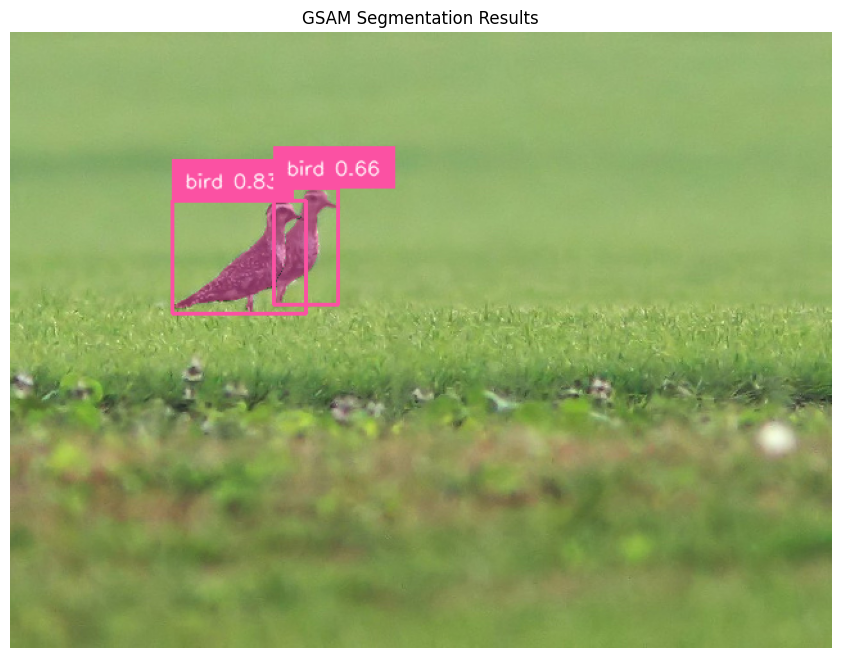

In [ ]:
# Display GSAM visualization if available
if 'visualized_output' in locals() and visualized_output is not None:
    print("Displaying GSAM segmentation visualization...")
    plt.figure(figsize=(12, 8))
    plt.imshow(visualized_output)
    plt.title("GSAM Segmentation Results")
    plt.axis('off')
    plt.show()
else:
    print("No GSAM visualization available")


In [ ]:
# Save annotation data for FLUX generation
if step3_data_list and img_array is not None and img_info is not None and caption is not None:



Saving annotation data for FLUX generation...
✅ Annotation data saved:
  Annotations: notebooks/annotations/552678_20250828_230415_step3_step3_data.json
  Image array: notebooks/annotations/552678_20250828_230415_step3_image.npy
  Visualization: notebooks/annotations/552678_20250828_230415_step3_visualization.npy
  Base filename: 552678_20250828_230415_step3
\n📝 To load this data in the FLUX notebook, use step3_id: '552678_20250828_230415_step3'


In [ ]:
# Cleanup and summary
print("\\nCleaning up GSAM models...")

# Cleanup models
try:
    gsam_detector.cleanup()
    print("✅ GSAM models cleaned up")
except:
    pass

# Print summary
print("\\n" + "="*60)
print("GSAM ANNOTATION GENERATION SUMMARY")
print("="*60)

if 'img_info' in locals() and img_info:
    print(f"Image processed: {img_info['file_name']} (ID: {img_info['id']})")
if 'caption' in locals() and caption:
    print(f"Caption: {caption}")
if 'step3_data_list' in locals() and step3_data_list:
    print(f"Overlapping entity pairs found: {len(step3_data_list)}")
    # Display step 3 data summary
    print(f"Found {len(step3_data_list)} overlapping entity pairs:")
else:
    print("Artifacts generated: 0")

if 'money_manager' in locals():
    print(f"Total API cost: ${money_manager.total_cost:.4f}")

if 'saved_step3_id' in locals() and saved_annotation_id:
    print(f"\\n✅ Annotation data saved with ID: {saved_annotation_id}")
    print("Next step: Use this ID in the FLUX generation notebook")
else:
    print("\\n❌ No annotation data was saved")

print("="*60)


\nCleaning up GSAM models...
✅ GSAM models cleaned up
\n============================================================
GSAM ANNOTATION GENERATION SUMMARY
Image processed: 000000552678.jpg (ID: 552678)
Caption: two birds standing in the grass on a green field
Overlapping entity pairs found: 2
Found 2 overlapping entity pairs:
Total API cost: $0.0000
\n❌ No annotation data was saved
